# Batch Segmentation for Remote Sensing Imagery with SAM 3

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/segment-geospatial/blob/main/docs/examples/sam3_batch_segmentation.ipynb)

This notebook demonstrates how to do batch segmentation for remote sensing imagery with SAM 3.

## Installation

First, make sure you have the required dependencies installed:

In [1]:
%pip install "segment-geospatial[samgeo3]"

Note: you may need to restart the kernel to use updated packages.


## Import Libraries


In [2]:
import leafmap
from samgeo import SamGeo3, download_file

## Download Sample Data

Let's download sample satellite images covering the University of California, Berkeley, for testing:


In [3]:
image_paths = []
for i in range(1, 5):
    url = f"https://huggingface.co/datasets/giswqs/geospatial/resolve/main/uc_berkeley_{i}.tif"
    image_path = download_file(url)
    image_paths.append(image_path)

Downloading...
From: https://huggingface.co/datasets/giswqs/geospatial/resolve/main/uc_berkeley_1.tif
To: /media/gisense/xihan/250812_tamu_cybertraining_team4/SAM3/uc_berkeley_1.tif
100%|██████████| 12.7M/12.7M [00:00<00:00, 53.6MB/s]
Downloading...
From: https://huggingface.co/datasets/giswqs/geospatial/resolve/main/uc_berkeley_2.tif
To: /media/gisense/xihan/250812_tamu_cybertraining_team4/SAM3/uc_berkeley_2.tif
100%|██████████| 10.6M/10.6M [00:00<00:00, 71.0MB/s]
Downloading...
From: https://huggingface.co/datasets/giswqs/geospatial/resolve/main/uc_berkeley_3.tif
To: /media/gisense/xihan/250812_tamu_cybertraining_team4/SAM3/uc_berkeley_3.tif
100%|██████████| 8.69M/8.69M [00:00<00:00, 34.5MB/s]
Downloading...
From: https://huggingface.co/datasets/giswqs/geospatial/resolve/main/uc_berkeley_4.tif
To: /media/gisense/xihan/250812_tamu_cybertraining_team4/SAM3/uc_berkeley_4.tif
100%|██████████| 9.35M/9.35M [00:00<00:00, 43.8MB/s]


In [4]:
m = leafmap.Map()
for i, image_path in enumerate(image_paths):
    m.add_raster(image_path, layer_name=f"image_{i + 1}")
m

Map(center=[37.8715, -122.2635], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', '…

## Request access to SAM3

To use SAM3, you need to request access by filling out this form on Hugging Face: https://huggingface.co/facebook/sam3

Once you have access, uncomment the following code block and run it.

In [5]:
from huggingface_hub import login
login()

## Initialize SAM3

When initializing SAM3, you can choose the backend from "meta", or "transformers".

In [6]:
sam3 = SamGeo3(backend="meta", device=None, checkpoint_path=None, load_from_HF=True)

Using cuda device and meta backend


## Set the image batch

In [7]:
sam3.set_image_batch(image_paths)

Set 4 images for batch processing.


## Generate masks with text prompt

Generate masks for all images with a text prompt

In [8]:
sam3.generate_masks_batch("building", min_size=100)

Processed 4 image(s), found 174 total object(s).


In [9]:
# Access results for each image
for i, result in enumerate(sam3.batch_results):
    print(f"Image {i + 1}: Found {len(result['masks'])} objects")
    # result contains: masks, boxes, scores, image, source

Image 1: Found 46 objects
Image 2: Found 50 objects
Image 3: Found 64 objects
Image 4: Found 14 objects


## Show results

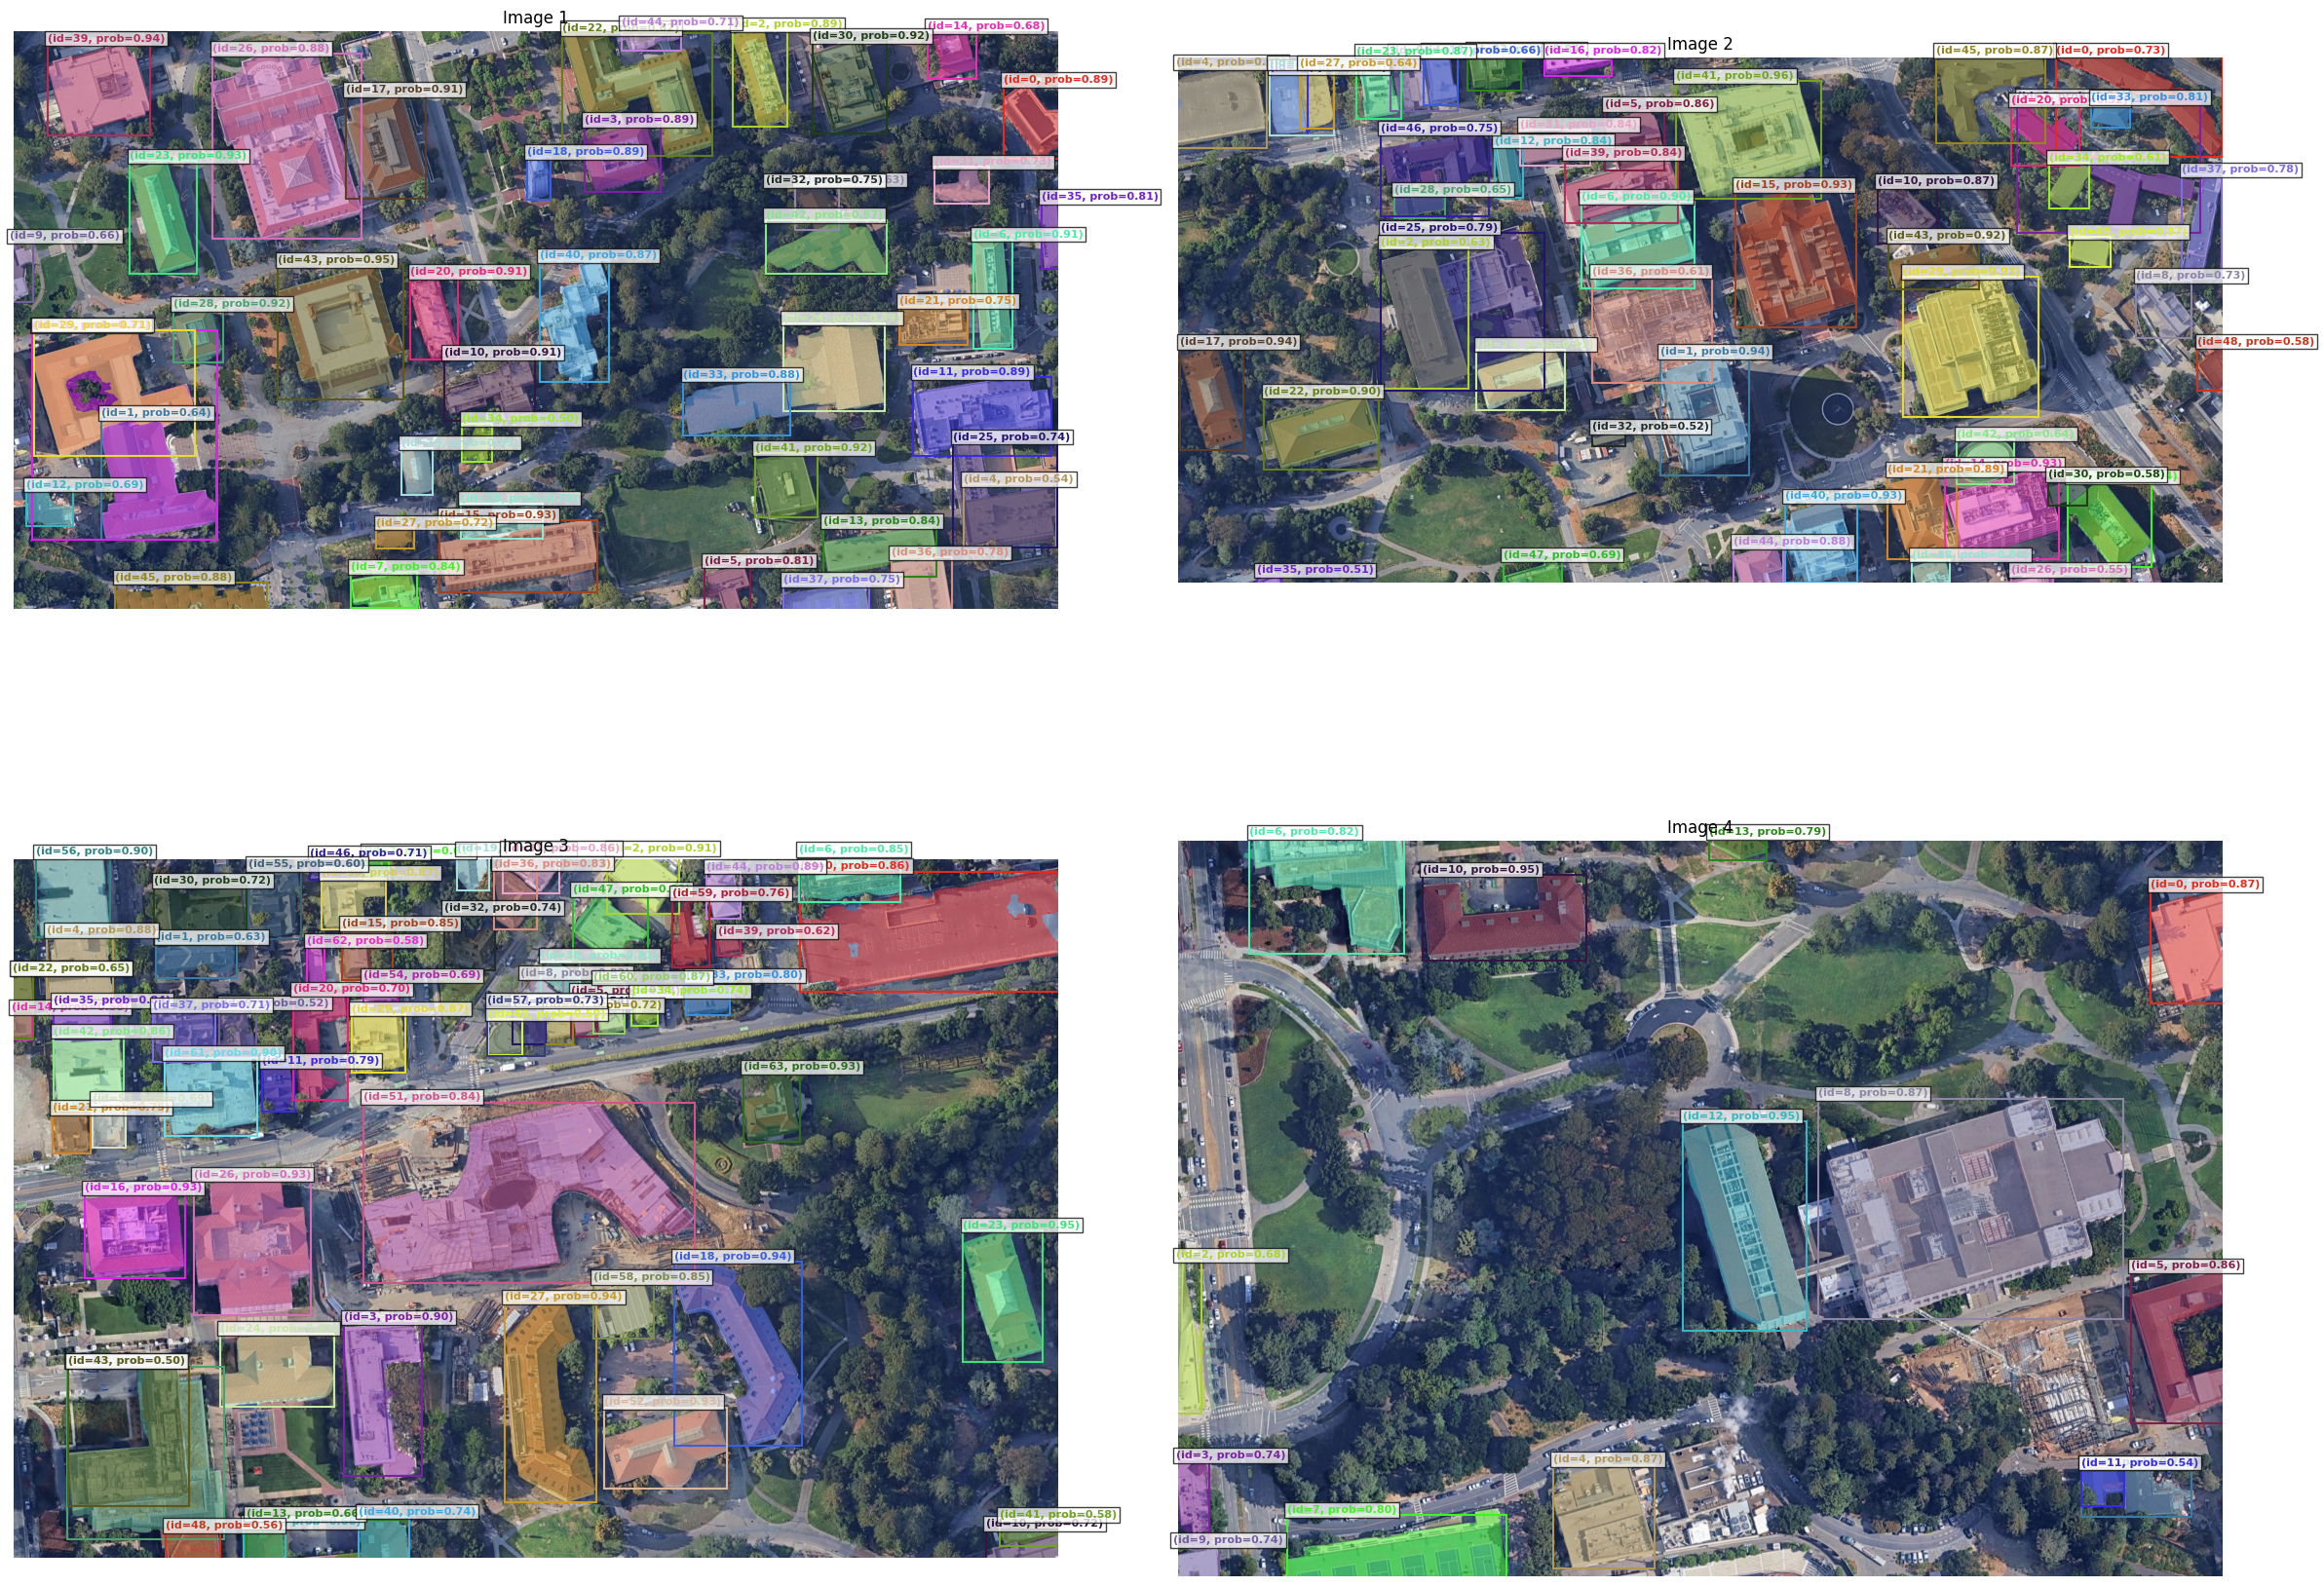

In [11]:
# Visualize all annotations in a grid
sam3.show_anns_batch(ncols=2, show_bbox=True, show_score=True)

![](https://github.com/user-attachments/assets/0c4f0b4b-4104-4a43-9173-ab76e0d2d71a)

## Save results

In [ ]:
sam3.show_anns_batch(output_dir="output/annotations/", prefix="ann", dpi=300)

In [ ]:
# Save all masks to disk
saved_files = sam3.save_masks_batch(
    output_dir="output/", prefix="building_mask", unique=True
)